#### Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter
from sklearn.model_selection import KFold
from scipy.stats import gaussian_kde, norm
from sklearn.model_selection import train_test_split
from matplotlib.ticker import FuncFormatter
from lifelines.plotting import add_at_risk_counts
from lifelines.utils import concordance_index

from __future__ import annotations
from collections import Counter
from dataclasses import dataclass
import hashlib
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

from lifelines.statistics import logrank_test

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

#### Datasets

In [83]:
lical0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/lical0_processed_data_for_fp_model_21-01-2026.csv')
miro0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/miro0_processed_data_for_fp_model_21-01-2026.csv')
ril_3010 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/ril_3010_processed_data_for_fp_model_21-01-2026.csv')

# miroli0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/miroli0_processed_data_for_fp_model_21-01-2026.csv')
proact0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/proact0_processed_data_for_fp_model_21-01-2026.csv')

MND_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_licals.csv')
MND_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_mirocals.csv')
MND_rilu = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_riluzole.csv')

In [84]:
proact0 = proact0[proact0['Disease_Duration'] < 120]

##### Proact with eligibility criteria

In [85]:
proact_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_miro_full.csv')
proact_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_lica_full.csv')

proact_miro['slope'] = (48 - proact_miro['ALSFRS_RT']) / proact_miro['Disease_Duration']
proact_lica['slope'] = (48 - proact_lica['ALSFRS_RT']) / proact_lica['Disease_Duration']

binss = [-np.inf, 0.31, 1.17, np.inf]
labelss = ["Slow", "Intermediate", "Fast"]

proact_miro["Progression_group"] = pd.cut(proact_miro["slope"], bins=binss, labels=labelss)
proact_lica["Progression_group"] = pd.cut(proact_lica["slope"], bins=binss, labels=labelss)


proact_miro['Study_Arm_Placebo'] = (proact_miro['Study_Arm'] == 'Placebo').astype(int)
proact_lica['Study_Arm_Placebo'] = (proact_lica['Study_Arm'] == 'Placebo').astype(int)

proact_miro = proact_miro[['subject_id', 'Event', 'Vital_Capacity_l_std', 'Sex_Male', 'Onset_Limb', 'Study_Arm_Placebo', 'Age_std', 'Diagnosis_delay_l_std', 'Disease_Duration', 'TRICALS', 'Sex_onset',	'Age_Sex', 'Age_onset', 'Age_sq', "Progression_group"]]
proact_lica = proact_lica[['subject_id', 'Event', 'Vital_Capacity_l_std', 'Sex_Male', 'Onset_Limb', 'Study_Arm_Placebo', 'Age_std', 'Diagnosis_delay_l_std', 'Disease_Duration', 'TRICALS', 'Sex_onset',	'Age_Sex', 'Age_onset', 'Age_sq', "Progression_group"]]

proact_miro = proact_miro.rename(columns={'Age_std': 'Age', 'Diagnosis_delay_l_std': 'Diagnostic_Delay', 'Vital_Capacity_l_std': 'Vital_capacity'})
proact_lica = proact_lica.rename(columns={'Age_std': 'Age', 'Diagnosis_delay_l_std': 'Diagnostic_Delay', 'Vital_Capacity_l_std': 'Vital_capacity'})


# print(f"proact_miro: {proact_miro.shape} | proact_lica: {proact_lica.shape}")
proact_lica.head(2)

,subject_id,Event,Vital_capacity,Sex_Male,Onset_Limb,Study_Arm_Placebo,Age,Diagnostic_Delay,Disease_Duration,TRICALS,Sex_onset,Age_Sex,Age_onset,Age_sq,Progression_group
0,1333,1,0.257074,0,1,0,-0.428923,0.605487,22.996058,-3.779545,0,-0.000000,-0.428923,0.183975,Fast
1,3350,0,1.381487,1,1,0,1.305237,0.462062,21.747700,-4.907534,1,1.305237,1.305237,1.703642,Intermediate


#### **Select only the treatment arm**

In [86]:
lical0_trt = lical0[lical0['Study_Arm_Placebo'] == 0].copy()
miro0_trt = miro0[miro0['Study_Arm_Placebo'] == 0].copy()
# miroli0_trt = miroli0[miroli0['Study_Arm_Placebo'] == 0].copy()
ril_3010_trt = ril_3010[ril_3010['Study_Arm_Placebo'] == 0].copy()
proact0_trt = proact0[proact0['Study_Arm_Placebo'] == 0].copy() 

#### **Select only the placebo arm**

In [87]:
lical0_pla = lical0[lical0['Study_Arm_Placebo'] == 1].copy()
miro0_pla = miro0[miro0['Study_Arm_Placebo'] == 1].copy()
# miroli0_pla = miroli0[miroli0['Study_Arm_Placebo'] == 1].copy()
ril_3010_pla = ril_3010[ril_3010['Study_Arm_Placebo'] == 1].copy()
proact0_pla = proact0[proact0['Study_Arm_Placebo'] == 1].copy() 

In [88]:
proact_miro_pla = proact_miro[proact_miro['Study_Arm_Placebo'] == 1]
proact_lica_pla = proact_lica[proact_lica['Study_Arm_Placebo'] == 1]

proact_miro_trt = proact_miro[proact_miro['Study_Arm_Placebo'] == 0]
proact_lica_trt = proact_lica[proact_lica['Study_Arm_Placebo'] == 0]

print(f"proact_miro_trt: {proact_miro_trt.shape} | proact_lica_trt: {proact_lica_trt.shape}\n")
print(f"proact_miro_pla: {proact_miro_pla.shape} | proact_lica_pla: {proact_lica_pla.shape}\n")
proact_lica_pla.head(2)

proact_miro_trt: (240, 15) | proact_lica_trt: (346, 15)

proact_miro_pla: (188, 15) | proact_lica_pla: (281, 15)



,subject_id,Event,Vital_capacity,Sex_Male,Onset_Limb,Study_Arm_Placebo,Age,Diagnostic_Delay,Disease_Duration,TRICALS,Sex_onset,Age_Sex,Age_onset,Age_sq,Progression_group
3,4753,1,-0.336316,0,1,1,-1.902391,-1.024997,14.586071,-2.589279,0,-0.0,-1.902391,3.619093,Fast
5,7540,0,0.043730,0,1,1,0.704515,0.685898,20.400788,-4.593248,0,0.0,0.704515,0.496341,Intermediate


In [89]:
print(f"Miro: {miro0_pla.Disease_Duration.describe().round(2).to_dict()}\n")
# print(f"miroli: {miroli0_pla.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"Lical :{lical0_pla.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"Riluzole: {ril_3010_pla.Disease_Duration.describe().round(2).to_dict()}\n")

print(f"Proact: {proact0_pla.Disease_Duration.describe().round(2).to_dict()}\n")

print(f"MND_lica: {MND_lica.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"MND_miro: {MND_miro.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"MND_rilu: {MND_rilu.Disease_Duration.describe().round(2).to_dict()}\n")

Miro: {'count': 110.0, 'mean': 29.04, 'std': 8.09, 'min': 8.05, '25%': 25.14, '50%': 29.35, '75%': 34.32, 'max': 44.92}

Lical :{'count': 87.0, 'mean': 31.76, 'std': 8.63, 'min': 10.86, '25%': 24.95, '50%': 34.81, '75%': 37.67, 'max': 46.14}

Riluzole: {'count': 242.0, 'mean': 13.41, 'std': 5.41, 'min': 0.3, '25%': 9.2, '50%': 15.82, '75%': 17.94, 'max': 20.7}

Proact: {'count': 1547.0, 'mean': 29.64, 'std': 11.36, 'min': 4.66, '25%': 21.83, '50%': 27.9, '75%': 35.41, 'max': 100.1}

MND_lica: {'count': 146.0, 'mean': 23.87, 'std': 7.56, 'min': 7.13, '25%': 18.32, '50%': 24.56, '75%': 30.42, 'max': 35.94}

MND_miro: {'count': 92.0, 'mean': 18.8, 'std': 5.62, 'min': 5.22, '25%': 14.82, '50%': 19.73, '75%': 24.08, 'max': 27.92}

MND_rilu: {'count': 169.0, 'mean': 29.55, 'std': 11.92, 'min': 5.65, '25%': 20.86, '50%': 29.53, '75%': 36.24, 'max': 59.92}



#### Choosing cohorts

In [90]:
MND_lica.columns

Index(['subject_id', 'Event', 'Disease_Duration', 'Age', 'Diagnostic_Delay',
       'Sex_Male', 'Onset_Limb', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq',
       'TRICALS_Risk_Score'],
      dtype='object')

In [91]:
lical0_trt.columns

Index(['subject_id', 'Event', 'Disease_Duration', 'Study_Arm_Placebo', 'Age',
       'TRICALS', 'Diagnostic_Delay', 'Vital_capacity', 'Onset_Limb',
       'Sex_Male', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_TRICALS',
       'Age_VC', 'Sex_VC', 'Onset_VC', 'Age_sq'],
      dtype='object')

In [92]:
MND_miro['Study_Arm_Placebo'] = 1
MND_lica['Study_Arm_Placebo'] = 1

MND_miro = MND_miro.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})
MND_lica = MND_lica.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})

miro0_trt_mnd = miro0_trt[['subject_id', 'Event', 'Disease_Duration','Study_Arm_Placebo', 'Age', 'Diagnostic_Delay',
       'Sex_Male', 'Onset_Limb', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq', 'TRICALS']]
lical0_trt_mnd = lical0_trt[['subject_id', 'Event', 'Disease_Duration','Study_Arm_Placebo', 'Age', 'Diagnostic_Delay',
       'Sex_Male', 'Onset_Limb', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq', 'TRICALS']]


miro_trt_trical = miro0_trt[(miro0_trt['TRICALS'] >= -6) & (miro0_trt['TRICALS'] <= -2)]
MND_miro_trical = MND_miro[(MND_miro['TRICALS'] >= -6) & (MND_miro['TRICALS'] <= -2)]

lica_trt_trical = lical0_trt[(lical0_trt['TRICALS'] >= -6) & (lical0_trt['TRICALS'] <= -2)]
MND_lica_trical = MND_lica[(MND_lica['TRICALS'] >= -6) & (MND_lica['TRICALS'] <= -2)]


In [93]:
# combine mirocals treated and licals placebo
comb = pd.concat([lical0_trt, MND_lica], axis=0, ignore_index=True)
comb['Group'] = (comb['Study_Arm_Placebo'] == 0).astype(int)
comb.shape

(235, 19)

In [94]:
comb.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,TRICALS,Diagnostic_Delay,Vital_capacity,Onset_Limb,Sex_Male,Sex_onset,Age_Sex,Age_onset,Age_TRICALS,Age_VC,Sex_VC,Onset_VC,Age_sq,Group
0,P01003,0,34.571616,0,-1.105049,-1.025245,0.017917,0.676193,1,1,1,-1.105049,-1.105049,1.132946,-0.747226,0.676193,0.676193,1.221133,1
1,P01004,0,28.428384,0,-1.059473,-0.706113,-1.452295,0.522667,1,1,1,-1.059473,-1.059473,0.748108,-0.553751,0.522667,0.522667,1.122482,1


In [95]:
# ============================================================
# PROPENSITY SCORE + OVERLAP
# ============================================================
def fit_propensity_score(
    df: pd.DataFrame,
    covariates: List[str],
    penalty: str = "l2",
    C: float = 1.0
) -> Tuple[pd.DataFrame, Pipeline]:
    """
    Logistic PS model: probability of being in treated trial arm.
    Missing numeric values are median-imputed.
    """
    x = df[covariates].copy()
    y = df["Group"].astype(int).values

    numeric_features = covariates
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features)
        ],
        remainder="drop"
    )

    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver="lbfgs",
        max_iter=5000
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(x, y)
    ps = pipe.predict_proba(x)[:, 1]

    out = df.copy()
    out["ps"] = ps
    out["ps_logit"] = np.log(np.clip(ps, 1e-6, 1-1e-6) / np.clip(1-ps, 1e-6, 1-1e-6))

    auc = roc_auc_score(y, ps)
    print(f"Propensity model AUC: {auc:.3f}")

    return out, pipe

In [96]:
covariates = ['Disease_Duration', 'Age', 'Diagnostic_Delay', 'Onset_Limb', 'Sex_Male'] #, 'Vital_capacity']

comb_ps, propen = fit_propensity_score(comb, covariates)
# 
comb_ps.head(2)

Propensity model AUC: 0.775


,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,TRICALS,Diagnostic_Delay,Vital_capacity,Onset_Limb,Sex_Male,Sex_onset,Age_Sex,Age_onset,Age_TRICALS,Age_VC,Sex_VC,Onset_VC,Age_sq,Group,ps,ps_logit
0,P01003,0,34.571616,0,-1.105049,-1.025245,0.017917,0.676193,1,1,1,-1.105049,-1.105049,1.132946,-0.747226,0.676193,0.676193,1.221133,1,0.656577,0.648077
1,P01004,0,28.428384,0,-1.059473,-0.706113,-1.452295,0.522667,1,1,1,-1.059473,-1.059473,0.748108,-0.553751,0.522667,0.522667,1.122482,1,0.717652,0.932844


In [97]:
# Trim non overlapping records
def trim_nonoverlap(df: pd.DataFrame, ps_col: str = "ps") -> pd.DataFrame:
    """
    Trim non-overlapping tails:
      treated above max(control) and control below min(treated)
    """
    x = df.copy()
    ps_t = x.loc[x["Group"] == 1, ps_col]
    ps_c = x.loc[x["Group"] == 0, ps_col]

    lower = ps_t.min()
    upper = ps_c.max()

    # More symmetric overlap region
    lower_common = max(ps_t.min(), ps_c.min())
    upper_common = min(ps_t.max(), ps_c.max())

    trimmed = x[(x[ps_col] >= lower_common) & (x[ps_col] <= upper_common)].copy()

    print(f"Before trimming: {len(x)}")
    print(f"After trimming:  {len(trimmed)}")
    print(f"Removed:         {len(x) - len(trimmed)}")

    return trimmed.reset_index(drop=True)

trim_propen = trim_nonoverlap(comb_ps, "ps")
# trim_propen

Before trimming: 235
After trimming:  207
Removed:         28


In [98]:
# make treated and contral groups more comparable
def add_weights(df: pd.DataFrame, method: str = "overlap", ps_col: str = "ps") -> pd.DataFrame:
    """
    Supported:
      - overlap
      - iptw
      - unstabilized
    """
    x = df.copy()
    ps = np.clip(x[ps_col].values, 1e-6, 1 - 1e-6)
    g = x["Group"].values

    if method == "overlap":
        w = np.where(g == 1, 1 - ps, ps)
    elif method in ("iptw", "unstabilized"):
        w = np.where(g == 1, 1 / ps, 1 / (1 - ps))
    else:
        raise ValueError("method must be 'overlap' or 'iptw'")

    x["weight"] = w
    return x

comb_weight = add_weights(comb_ps)
comb_weight.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,TRICALS,Diagnostic_Delay,Vital_capacity,Onset_Limb,Sex_Male,Sex_onset,Age_Sex,Age_onset,Age_TRICALS,Age_VC,Sex_VC,Onset_VC,Age_sq,Group,ps,ps_logit,weight
0,P01003,0,34.571616,0,-1.105049,-1.025245,0.017917,0.676193,1,1,1,-1.105049,-1.105049,1.132946,-0.747226,0.676193,0.676193,1.221133,1,0.656577,0.648077,0.343423
1,P01004,0,28.428384,0,-1.059473,-0.706113,-1.452295,0.522667,1,1,1,-1.059473,-1.059473,0.748108,-0.553751,0.522667,0.522667,1.122482,1,0.717652,0.932844,0.282348


In [99]:
# ============================================================
# BALANCE DIAGNOSTICS
# ============================================================
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)


def weighted_var(x, w):
    mu = weighted_mean(x, w)
    return np.sum(w * (x - mu) ** 2) / np.sum(w)


def smd_continuous(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        mt = np.nanmean(x_t)
        vt = np.nanvar(x_t, ddof=0)
    else:
        mt = weighted_mean(x_t, w_t)
        vt = weighted_var(x_t, w_t)

    if w_c is None:
        mc = np.nanmean(x_c)
        vc = np.nanvar(x_c, ddof=0)
    else:
        mc = weighted_mean(x_c, w_c)
        vc = weighted_var(x_c, w_c)

    pooled_sd = np.sqrt((vt + vc) / 2)
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return np.nan
    return (mt - mc) / pooled_sd


def smd_binary(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        pt = np.nanmean(x_t)
    else:
        pt = weighted_mean(x_t, w_t)

    if w_c is None:
        pc = np.nanmean(x_c)
    else:
        pc = weighted_mean(x_c, w_c)

    p = (pt + pc) / 2
    denom = np.sqrt(p * (1 - p))
    if denom == 0 or np.isnan(denom):
        return np.nan
    return (pt - pc) / denom


def balance_table(df: pd.DataFrame, covariates: List[str], weight_col: Optional[str] = None) -> pd.DataFrame:
    rows = []

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    for col in covariates:
        xt = treated[col].astype(float)
        xc = control[col].astype(float)

        mask_t = xt.notna()
        mask_c = xc.notna()
        xt = xt[mask_t]
        xc = xc[mask_c]

        wt = treated.loc[mask_t, weight_col].values if weight_col is not None else None
        wc = control.loc[mask_c, weight_col].values if weight_col is not None else None

        uniq = pd.concat([xt, xc]).dropna().unique()
        is_binary = set(np.unique(uniq)).issubset({0.0, 1.0})

        if is_binary:
            smd = smd_binary(xt, xc, wt, wc)
        else:
            smd = smd_continuous(xt, xc, wt, wc)

        if weight_col is None:
            mt = np.nanmean(xt)
            mc = np.nanmean(xc)
        else:
            mt = weighted_mean(xt.values, wt)
            mc = weighted_mean(xc.values, wc)

        rows.append({
            "Variable": col,
            "Treated_mean": mt,
            "Control_mean": mc,
            "SMD": smd,
            "Abs_SMD": np.abs(smd)
        })

    out = pd.DataFrame(rows).sort_values("Abs_SMD", ascending=False).reset_index(drop=True)
    return out

comb_baln = balance_table(comb_weight, covariates, 'weight')
comb_baln

,Variable,Treated_mean,Control_mean,SMD,Abs_SMD
0,Onset_Limb,0.782667,0.771905,0.025866,0.025866
1,Sex_Male,0.711054,0.700417,0.023340,0.023340
2,Diagnostic_Delay,-0.202347,-0.184561,-0.016537,0.016537
3,Age,-0.005431,-0.008815,0.003375,0.003375
4,Disease_Duration,26.982567,26.971588,0.001302,0.001302


In [100]:
# ============================================================
# SURVIVAL ANALYSIS
# ============================================================
def weighted_km_plot(
    df: pd.DataFrame,
    time_col: str = "Time",
    event_col: str = "Event",
    weight_col: Optional[str] = "weight",
    title: str = "Weighted Kaplan-Meier",
    x_max: Optional[float] = None
):
    plt.figure(figsize=(5, 4))

    km_t = KaplanMeierFitter()
    km_c = KaplanMeierFitter()

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    km_t.fit(
        durations=treated[time_col],
        event_observed=treated[event_col],
        weights=treated[weight_col] if weight_col else None,
        label="Treated"
    )
    km_c.fit(
        durations=control[time_col],
        event_observed=control[event_col],
        weights=control[weight_col] if weight_col else None,
        label="External control"
    )

    ax = km_t.plot_survival_function(ci_show=True)
    km_c.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlabel("Disease Duration")
    ax.set_ylabel("Survival probability")
    ax.set_title(title)
    ax.set_ylim(0,1.02)
    ax.grid(True, alpha=0.3)
    if x_max is not None:
        ax.set_xlim(0, x_max)
    plt.tight_layout()
    plt.show()
    

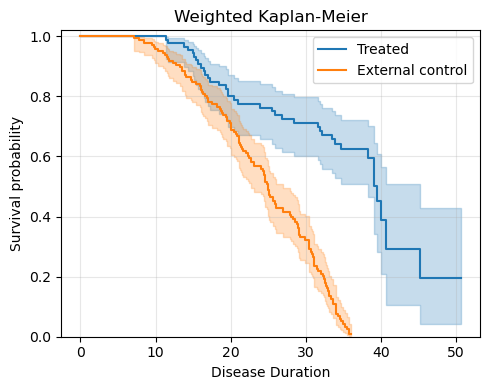

In [101]:
weighted_km_plot(comb_weight, time_col = "Disease_Duration", event_col = "Event",weight_col = None)

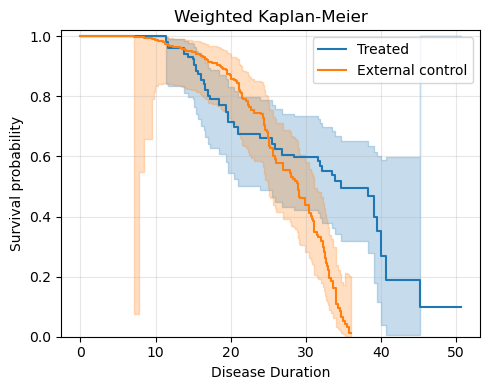

In [102]:
weighted_km_plot(comb_weight, time_col = "Disease_Duration", event_col = "Event",weight_col = "weight")

#### **Helper function**

In [ ]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================
def _clip_prob(p: np.ndarray | float, eps: float = 1e-12):
    """ clip probs to (esp, 1-eps) to avoid infinities.
        p_clipped  = min(max(p, eps), 1 - eps)"""
    return np.clip(p, eps, 1 - eps)


def _logit(p: np.ndarray | float) ->np.ndarray | float:
    """ logit transformation.
        
        logit(p) = log( p / (1 - p) )"""
    p = _clip_prob(np.asarray(p, dtype = float))
    return np.log(p / (1.0 - p))

def _expit(z: np.ndarray | float) -> np.ndarray | float:
    """ logistic inverse.

        expit(z) = 1 / (1 + exp(-z)) """
    z = np.asarray(z, dtype = float)
    return 1.0 / (1.0 + np.exp(-z))


# ============================================================
# DATA PREPARATION
# ============================================================
def pred_df(
    df: pd.DataFrame,
    covariates: list[str],
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    entry_col: str | None = None,
) -> pd.DataFrame:
    """ Keep only analysis columns and enforce numeric/event types. """
    cols = [time_col, event_col] + list(covariates)
    if entry_col is not None:
        cols.append(entry_col)

    out = df.loc[:, [c for c in cols if c in df.columns]].copy()
    out[event_col] = out[event_col].astype(int)

    # Enforce numeric for all model columns where possible
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors = "coerce")

    out = out.dropna(subset=[time_col, event_col] + covariates)
    if entry_col is not None:
        out = out.dropna(subset=[entry_col])

    return out.reset_index(drop=True)


# ============================================================
# Model fitting
# ============================================================
def fit_coxph(
    df: pd.DataFrame,
    covariates: list[str],
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    entry_col: str | None = None,
    penalizer: float = 0.0,
    l1_ratio: float = 0.0,
    strata: list[str] | None = None,
    robust: bool = False,
) -> CoxPHFitter:
    """ Fit a cox ph hazards model.

     h(t|x) = h0(t) * exp((x - x_bar)^T beta). """
    cols = [time_col, event_col] + list(covariates)
    if entry_col is not None:
        cols.append(entry_col)
    if strata is not None:
        cols += list(strata)

    df_fit = df[cols].copy()

    cph = CoxPHFitter(
        penalizer = penalizer,
        l1_ratio = l1_ratio,
        strata = strata,
    )
    cph.fit(
        df_fit,
        duration_col=time_col,
        event_col=event_col,
        entry_col=entry_col,
        robust=robust,
    )
    return cph


def fit_coxph_and_partial_aic(
    df: pd.DataFrame,
    covariates: list[str],
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    entry_col: str | None = None,
    penalizer: float = 0.0,
    l1_ratio: float = 0.0,
) -> tuple[CoxPHFitter, float]:
    """ fit cox ph and return the model plus its patial aic.
    Approximate AIC used by lifelines:
    partial AIC = -2 * partial log-likelihood + 2*p"""

    cph = fit_coxph(
        df=df,
        covariates=covariates,
        time_col=time_col,
        event_col=entry_col,
        entry_col=entry_col,
        penalizer=penalizer,
        l1_ratio=l1_ratio,
    )

    # lifelines exposes partial_AIC_ for cox with breslow baseline
    aic = float(cph.partial_AIC_)
    return cph, aic


# ============================================================
# Prognostic score / linear predictor
# ============================================================
def predict_lp_from_cox(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
) ->np.ndarray:
    """ Compute the linear predictor (log partial hazard) 
    eta = (x - x_bar)^T beta 
    
    larger hazard => worse prognosis """
    X = df[covariates].copy()
    lp = model.predict_log_partial_hazard(X)
    return np.asarray(lp, dtype = float).reshape(-1)


def predict_partial_hazard_from_cox(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
) -> np.ndarray:
    """ compute partial hazard.
        ph = exp(eta) """
    X = df[covariates].copy()
    ph = model.predict_partial_hazard(X)
    return np.asarray(ph, dtype = float).reshape(-1)


# ============================================================
# Survival and risk at fixed horizon t0
# ============================================================
def predict_surv_at_t0(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
) -> np.ndarray:
    """ predict subject-specific survival prob at time t0 
    S(t0 | x) = S0(t0) ^ exp(eta) """
    X = df[covariates].copy()
    sf = model.predict_survival_function(X, times=[float(t0_months)])
    return np.asarray(sf.iloc[0, :], dtype = float)


def predict_risk_at_t0(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
) -> np.ndarray:
    """ predict subject-specific event risk by t0
    p(t0) =  1 - S(t0 | x) """
    S_pred = predict_surv_at_t0(model, df, covariates, t0_months)
    return 1.0 - S_pred

# ============================================================
# Kaplan-Meier helpers
# ============================================================
def km_surv_at_t0(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> float:
    """ Kaplan-Meier estimate of survival at t0 """
    kmf = KaplanMeierFitter()
    kmf.fit(df[time_col], event_observed=df[event_col])

    out = kmf.survival_function_at_times([float(t0_months)])
    val = float(out.iloc[0])

    return val


def km_risk_ci_at_t0(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> tuple[float, float, float]:
    """ Kaplan-Meier risk and approximate 95% CI at t0
    (risk, lower, upper)
       where risk = 1 - S_hat_Km(t0) """
    kmf = KaplanMeierFitter()
    kmf.fit(df[time_col], event_observed = df[event_col])

    # survival estimate at t0
    S = float(kmf.survival_function_at_times([float(t0_months)]).iloc[0])

    # confidence interval tables are indexec by event times:
    # use forward-fill to align with t0.
    ci = kmf.confidence_interval_survival_function_.copy()
    ci = ci.sort_index()

    all_times = np.sort(np.unique(np.r_[ci.index.values.astype(float), float(t0_months)]))
    ci2 = ci.reindex(all_times).ffill()
    row = ci2.loc[float(t0_months)]

    # Assume first column is lower, second is upper
    lo_s = float(row.iloc[0])
    hi_s = float(row.iloc[1])

    risk = 1.0 - S
    risk_lo = 1.0 - hi_s
    risk_hi = 1.0 - lo_s

    return float(risk), float(risk_lo), float(risk_hi)


# ============================================================
# Discrimination and calibration slope
# ============================================================
def cindex_from_risk_score(
    df: pd.DataFrame,
    score: np.ndarray,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> float:
    """ Harrel's C-index from a risk score. 
     higher score = shorter survival = higher hazard 

     pass -score

     C = P(predicted ordering agrees with observed ordering)
     over comparable subject pairs. """
    score = np.asarray(score, dtype=float).reshape(-1)
    return float(
        concordance_index(
            event_times = df[time_col].to_numpy(dtype=float),
            predicted_scores = -score,
            event_observed=df[event_col].to_numpy(dtype=int),
        )
    )


def slope_from_risk_score(
   df: pd.DataFrame,
   score: np.ndarray,
   time_col: str = "Disease_Duration",
   event_col: str = "Event",
   entry_col: str | None = None, 
) -> float:
    """ calibration slope from a univariable cox model using the prognostic score.
    h(t|score) = h0(t) * exp(gamma * score)

    the estimated coefficient gamma is the calibration slope """

    tmp = df[[time_col, event_col]].copy()
    if entry_col is not None:
        tmp[entry_col] = df[entry_col].to_numpy()
    tmp["score"] = np.asarray(score, dtype=float)

    cph = CoxPHFitter()
    cph.fit(
        tmp,
        duration_col = time_col,
        event_col = event_col,
        entry_col = entry_col,
    )

    return float(cph.params_["score"])


# ============================================================
# CITL and IPCW logistic recalibration at t0
# ============================================================
def citl_at_t0(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> float:
    """ calibration in the large (simple fixed-horizon version).

    CITL(t0) = logit(p_obs(t0)) - logit(mean p_pred(t0))

    where: p_pred(t0) = 1 - S(t0|x)
            p_obs(t0) = 1 - S_hat_KM(t0) """

    p_pred = predict_risk_at_t0(model, df, covariates, t0_months)
    p_bar = float(np.mean(p_pred))

    S_km = km_surv_at_t0(df, t0_months, time_col=time_col, event_col=event_col)
    p_obs = 1.0 - float(S_km)

    return float(_logit(p_obs) - _logit(p_bar))


def _km_censoring_survival(
    time: np.ndarray,
    status: np.ndarray,
) -> KaplanMeierFitter:
    """ esimate censoring survival G(t) using K-M.

    here censoring is treated as the event: 
    C_i = 1 - status_i

    So: G(t) = P(censoring time > t )"""

    kmf = KaplanMeierFitter()
    censor_event = 1 - status
    kmf.fit(time, event_observed=censor_event)
    return kmf


def _G_at(kmf: KaplanMeierFitter, t: float) -> float:
    """ Return censoring survival estimate G(t) """

    val = float(kmf.survival_function_at_times([float(t)]).iloc[0])
    return max(val, 1e-12)


def ipcw_intercept_and_slope_t0_from_pred_risk(
    df: pd.DataFrame,
    p_pred: np.ndarray,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    estimate_slope: bool = True,
    max_iter: int = 100,
    tol: float = 1e-8,
) -> tuple[float, float | None]:
    """
    IPCW logistic recalibration at a fixed horizon t0.

    Target binary outcome:
        Y_i(t0) = I(T_i <= t0 and event_i = 1)

    Weights:
        w_i = 1 / G(T_i)   if event observed by t0
        w_i = 1 / G(t0)    if known event-free at t0 (T_i >= t0)
        w_i = 0            otherwise

    Recalibration model:
        logit(P(Y_i=1)) = alpha + beta * logit(p_pred,i)

    If estimate_slope=False:
        beta is fixed to 1 and only alpha is estimated.

    This is a simple IRLS implementation for weighted logistic regression
    with one predictor, avoiding a statsmodels dependency.
    """

    